# All the steps we which we are going to perform are following -:

### 1. Load Dataset
### 2. Data Cleaning
### 3. Feature Engineering
### 4. Exploratory Data Analysis (EDA)
### 5. Data Aggregation
### 6. Store in Database
### 7. Build Dashboard
### 8. Energy Optimization Insights

# Step 1 — Load the Dataset

In [14]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
df = pd.read_csv('household_power_consumption.csv',sep = ',', na_values = ['?'])

In [19]:
df.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
5,16/12/2006,17:29:00,3.520,0.522,235.02,15.0,0.0,2.0,17.0
6,16/12/2006,17:30:00,3.702,0.520,235.09,15.8,0.0,1.0,17.0
7,16/12/2006,17:31:00,3.700,0.520,235.22,15.8,0.0,1.0,17.0
8,16/12/2006,17:32:00,3.668,0.510,233.99,15.8,0.0,1.0,17.0
9,16/12/2006,17:33:00,3.662,0.510,233.86,15.8,0.0,2.0,16.0


In [20]:
df.tail(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1048565,13/12/2008,21:29:00,0.420,0.070,240.52,1.8,0.0,0.0,0.0
1048566,13/12/2008,21:30:00,0.418,0.070,240.24,1.8,0.0,0.0,0.0
1048567,13/12/2008,21:31:00,0.418,0.070,240.58,1.8,0.0,0.0,0.0
1048568,13/12/2008,21:32:00,0.420,0.068,239.96,1.8,0.0,0.0,0.0
1048569,13/12/2008,21:33:00,0.422,0.072,240.54,1.8,0.0,0.0,0.0
1048570,13/12/2008,21:34:00,0.426,0.076,242.27,1.8,0.0,0.0,0.0
1048571,13/12/2008,21:35:00,0.424,0.076,242.10,1.8,0.0,0.0,0.0
1048572,13/12/2008,21:36:00,0.422,0.076,241.73,1.8,0.0,0.0,0.0
1048573,13/12/2008,21:37:00,0.422,0.078,242.56,1.8,0.0,0.0,0.0
1048574,13/12/2008,21:38:00,0.422,0.078,242.61,1.8,0.0,0.0,0.0


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  str    
 1   Time                   1048575 non-null  str    
 2   Global_active_power    1044506 non-null  float64
 3   Global_reactive_power  1044506 non-null  float64
 4   Voltage                1044506 non-null  float64
 5   Global_intensity       1044506 non-null  float64
 6   Sub_metering_1         1044506 non-null  float64
 7   Sub_metering_2         1044506 non-null  float64
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(7), str(2)
memory usage: 72.0 MB


In [22]:
df.isnull().sum()

Date                        0
Time                        0
Global_active_power      4069
Global_reactive_power    4069
Voltage                  4069
Global_intensity         4069
Sub_metering_1           4069
Sub_metering_2           4069
Sub_metering_3           4069
dtype: int64

In [23]:
df.shape

(1048575, 9)

In [24]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='str')

In [25]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06
mean,1.108202e+00,1.182732e-01,2.399598e+02,4.718123e+00,1.177451e+00,1.475177e+00,5.933837e+00
std,1.129546e+00,1.095062e-01,3.284504e+00,4.763588e+00,6.321183e+00,6.352703e+00,8.210398e+00
min,7.600000e-02,0.000000e+00,2.234900e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.880000e-01,0.000000e+00,2.379700e+02,1.200000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.500000e-01,9.800000e-02,2.402100e+02,2.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.544000e+00,1.860000e-01,2.421400e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.067000e+01,1.390000e+00,2.521400e+02,4.640000e+01,8.000000e+01,7.800000e+01,3.100000e+01


# Progress made till now :-

### ✔ Step 1 — Load Dataset
### ⬜ Step 2 — Data Cleaning
### ⬜ Step 3 — Feature Engineering
### ⬜ Step 4 — Data Analysis
### ⬜ Step 5 — Database Storage
### ⬜ Step 6 — Dashboard

# Step 2 — Data Cleaning

### Check Missing Values
 
### First we check how many missing values exist.

In [26]:
df.isnull().sum()

Date                        0
Time                        0
Global_active_power      4069
Global_reactive_power    4069
Voltage                  4069
Global_intensity         4069
Sub_metering_1           4069
Sub_metering_2           4069
Sub_metering_3           4069
dtype: int64

### Convert Columns to Numeric

### Sometimes numeric columns are loaded as text (object).

In [27]:
df.dtypes

Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

### Remove Missing Values

In [28]:
df = df.dropna()

### Verify Missing Values Are Removed

In [29]:
df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

### Check Duplicate Rows

In [30]:
df.duplicated().sum()

np.int64(0)

### Check Dataset Size

In [31]:
df.shape

(1044506, 9)

### Inspect the Clean Data

df.head(10)

### Save Clean Dataset

In [32]:
df.to_csv("clean_energy_data.csv", index=False)

# Progress made till now :-

### ✔ Step 1 — Load Dataset
### ✔ Step 2 — Data Cleaning
### ⬜ Step 3 — Feature Engineering
### ⬜ Step 4 — Data Analysis
### ⬜ Step 5 — Database Storage
### ⬜ Step 6 — Dashboard

# Step 3 — Feature Engineering

### Create a Datetime Column
### Currently our dataset has two separate columns.
### For analysis we need one datetime column.

In [33]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='str')

In [34]:
df['Datetime'] = df['Date'] + " " + df['Time']

### Now converting that column into datetime format.

In [35]:
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%d/%m/%Y %H:%M:%S")

### Check the New Column

In [36]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


### Remove Old Columns 
### We don't need Date and Time anymore.

In [37]:
df = df.drop(["Date","Time"],axis = 1)

In [38]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


### Extract Hour Feature
### Electricity usage often changes during the day.

### Extract hour from datetime.

In [39]:
df["Hour"] = df["Datetime"].dt.hour

In [40]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Hour
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,17
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,17
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,17
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,17
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,17


### Now we can analyze which hour consumes most electricity.

### Extract Day Feature

In [41]:
df["Day"] = df["Datetime"].dt.day

In [42]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Hour,Day
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,17,16
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,17,16
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,17,16
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,17,16
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,17,16


### Extract Month Feature

In [43]:
df["Month"] = df["Datetime"].dt.month

In [44]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Hour,Day,Month
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,17,16,12
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,17,16,12
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,17,16,12
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,17,16,12
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,17,16,12


### Extract Year Feature

In [45]:
df["Year"] = df["Datetime"].dt.year

In [46]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Hour,Day,Month,Year
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,17,16,12,2006
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,17,16,12,2006
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,17,16,12,2006
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,17,16,12,2006
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,17,16,12,2006


### Calculating "Other Appliances" Power Consumption

### our dataset already contains power usage for three groups of appliances:

### Column	Appliance Type :-
#### *Sub_metering_1 ----  	Kitchen appliances
#### *Sub_metering_2 ----	Laundry appliances
#### *Sub_metering_3 ----	Water heater / AC

In [47]:
df["Other_Appliance"] = df["Global_active_power"]* 1000 / 60 - df["Sub_metering_1"] - df["Sub_metering_2"] - df["Sub_metering_2"]

In [48]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Hour,Day,Month,Year,Other_Appliance
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,17,16,12,2006,68.266667
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,17,16,12,2006,87.333333
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,17,16,12,2006,85.566667
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,17,16,12,2006,87.800000
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,17,16,12,2006,59.100000


### Save the Updated Dataset

In [49]:
df.to_csv("processed_energy_data.csv", index=False)

# Progress made till now :-

### ✔ Step 1 — Load Dataset
### ✔ Step 2 — Data Cleaning
### ✔ Step 3 — Feature Engineering
### ⬜ Step 4 — Data Analysis
### ⬜ Step 5 — Database Storage
### ⬜ Step 6 — Dashboard

# Step 4 — Exploratory Data Analysis (EDA)

### We will perform 5 important analyses:

1. Overall statistics
2. Hourly electricity consumption
3. Daily electricity consumption
4. Monthly electricity consumption
5. Appliance energy usage

### Overall Statistics

In [50]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Hour,Day,Month,Year,Other_Appliance
count,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1044506,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06,1.044506e+06
mean,1.108202e+00,1.182732e-01,2.399598e+02,4.718123e+00,1.177451e+00,1.475177e+00,5.933837e+00,2007-12-16 15:01:31.923033,1.150458e+01,1.569604e+01,6.506868e+00,2.007458e+03,1.434223e+01
min,7.600000e-02,0.000000e+00,2.234900e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2006-12-16 17:24:00,0.000000e+00,1.000000e+00,1.000000e+00,2.006000e+03,-7.236667e+01
25%,2.880000e-01,0.000000e+00,2.379700e+02,1.200000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2007-06-18 16:22:15,6.000000e+00,8.000000e+00,4.000000e+00,2.007000e+03,3.800000e+00
50%,5.500000e-01,9.800000e-02,2.402100e+02,2.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2007-12-17 03:10:30,1.200000e+01,1.600000e+01,7.000000e+00,2.007000e+03,7.066667e+00
75%,1.544000e+00,1.860000e-01,2.421400e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2008-06-15 11:25:45,1.800000e+01,2.300000e+01,9.000000e+00,2.008000e+03,2.316667e+01
max,1.067000e+01,1.390000e+00,2.521400e+02,4.640000e+01,8.000000e+01,7.800000e+01,3.100000e+01,2008-12-13 21:38:00,2.300000e+01,3.100000e+01,1.200000e+01,2.008000e+03,1.418333e+02
std,1.129546e+00,1.095062e-01,3.284504e+00,4.763588e+00,6.321183e+00,6.352703e+00,8.210398e+00,NaN,6.923520e+00,8.802004e+00,3.442266e+00,5.388726e-01,1.530546e+01


### What this tells :-
### *Average electricity usage
### *Maximum power consumption
### *Variation in power usage
### This gives a general overview of the dataset.

### Hourly Electricity Consumption
### Electricity usage changes throughout the day.

### Let's calculate average power usage per hour.

In [51]:
hourly_usage = df.groupby("Hour")["Global_active_power"].mean()

In [52]:
print(hourly_usage)

Hour
0     0.691493
1     0.550319
2     0.473297
3     0.438960
4     0.436185
5     0.452599
6     0.813300
7     1.478543
8     1.475767
9     1.309149
10    1.240883
11    1.208491
12    1.176721
13    1.132551
14    1.094618
15    1.011172
16    0.950998
17    1.034705
18    1.351102
19    1.829192
20    1.983174
21    1.993820
22    1.502395
23    0.961915
Name: Global_active_power, dtype: float64


### This shows which hour consumes the most electricity.

### Plot Hourly Electricity Usage
Let's visualize it.

In [53]:
import matplotlib.pyplot as plt

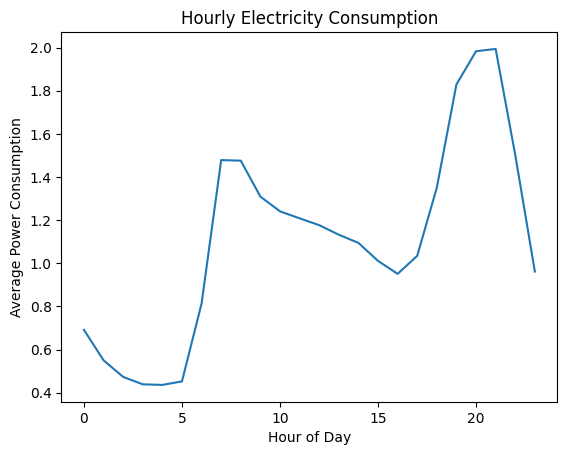

In [54]:
hourly_usage.plot()
plt.title("Hourly Electricity Consumption")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power Consumption")
plt.show()

### Daily Electricity Consumption
Now calculate total electricity used each day.

In [55]:
daily_usage = df.groupby("Day")["Global_active_power"].sum()

In [56]:
print(daily_usage)

Day
1     37238.558
2     35231.206
3     33259.614
4     40688.180
5     41078.110
6     39050.260
7     39409.692
8     40414.478
9     37299.598
10    37662.686
11    39112.966
12    38583.128
13    37756.552
14    36643.712
15    37044.830
16    38711.814
17    39835.208
18    40340.276
19    37427.892
20    40042.270
21    38027.756
22    39242.806
23    40380.382
24    39654.766
25    37271.444
26    33687.124
27    36061.258
28    34266.108
29    35362.938
30    31688.242
31    25049.960
Name: Global_active_power, dtype: float64


### Shows how electricity usage changes across days

### Plot Daily Electricity Usage
Let's visualize it.

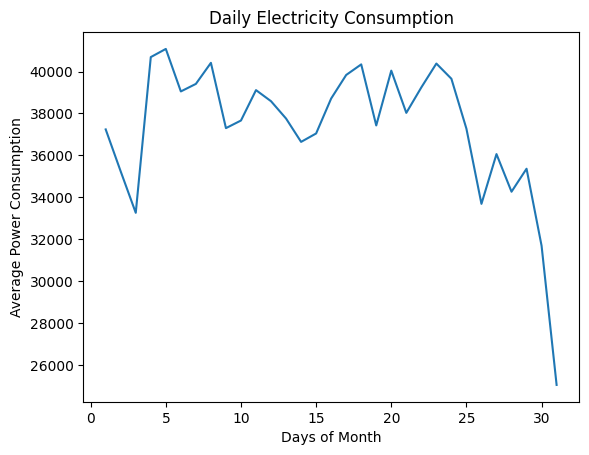

In [57]:
daily_usage.plot()
plt.title("Daily Electricity Consumption")
plt.xlabel("Days of Month")
plt.ylabel("Average Power Consumption")
plt.show()

### Shows how electricity usage changes across days.

### Monthly Electricity Consumption 

In [58]:
monthly_usage = df.groupby("Month")["Global_active_power"].mean()

In [59]:
print(monthly_usage)

Month
1     1.502977
2     1.289308
3     1.281982
4     1.008642
5     1.005071
6     0.910496
7     0.731166
8     0.520283
9     0.978499
10    1.120332
11    1.340766
12    1.636841
Name: Global_active_power, dtype: float64


### Montly Electricity Consumption
Now calculate average electricity used each month.

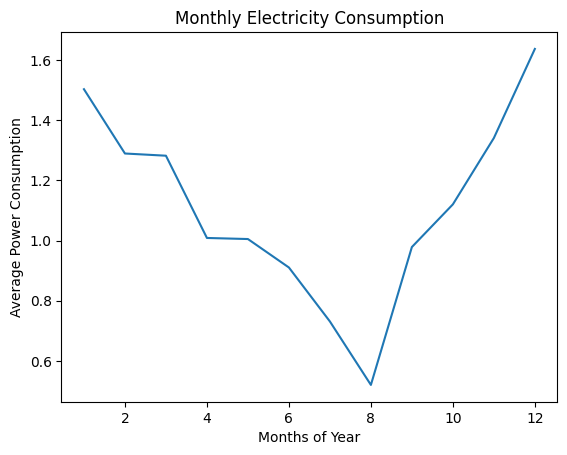

In [60]:
monthly_usage.plot()
plt.title("Monthly Electricity Consumption")
plt.xlabel("Months of Year")
plt.ylabel("Average Power Consumption")
plt.show()

### Higher usage in winter due to heaters.

### Appliance Energy Consumption
Now compare appliance power usage.

In [61]:
appliance_usage = df[["Sub_metering_1","Sub_metering_2","Sub_metering_3","Other_Appliance"]].mean()

In [62]:
print(appliance_usage)

Sub_metering_1      1.177451
Sub_metering_2      1.475177
Sub_metering_3      5.933837
Other_Appliance    14.342231
dtype: float64


###  Example Result -:
| Appliance        | Avg Consumption |
| ---------------- | --------------- |
| Kitchen          | 3               |
| Laundry          | 1               |
| Heater           | 7               |
| Other appliances | 5               |

### Insight

### Shows which appliances consume most electricity.


# Project Progress
### ✔ Step 1 — Load Dataset
### ✔ Step 2 — Data Cleaning
### ✔ Step 3 — Feature Engineering
### ✔ Step 4 — Exploratory Data Analysis
### ⬜ Step 5 — Database Storage

# Step 5 — Database Storage

### Install database connector:

In [63]:
pip install psycopg2-binary sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Connect Python to PostgreSQL

In [10]:
from sqlalchemy import create_engine

engine = create_engine(
"postgresql+psycopg2://postgres@localhost:5432/energy_project")

engine.connect()
print("Connected successfully")

Connected successfully


### Load Data Into Database

In [11]:
df.to_sql(
    "electricity_usage",
    engine,
    if_exists="replace",
    index=False
)

575

# Project Progress
### ✔ Step 1 — Load Dataset
### ✔ Step 2 — Data Cleaning
### ✔ Step 3 — Feature Engineering
### ✔ Step 4 — Exploratory Data Analysis
### ✔ Step 5 — Database Storage